# CelerisAi 1D Tutorial

This notebook reproduces the `setrun_1D.py` example and explains each setup step.

What you will do:
- Initialize Taichi
- Load 1D topography and wave forcing
- Build the domain and solver
- Run the model in display mode (or headless mode)

## Prerequisites
If you have not installed CelerisAi yet, you can do it just with:

From repository root:
```bash
pip install -e .
```

In [6]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

repo_root

PosixPath('/home/wrenteria/Documents/Github_Projects/CelerisAi')

## 1) Imports and backend

In [7]:
import taichi as ti

from celeris.domain import Topodata, BoundaryConditions, Domain
from celeris.solver import Solver
from celeris.runner import Evolve

# Use ti.cpu if you do not want GPU or need easier debugging
ti.init(arch=ti.gpu)

[Taichi] Starting on arch=cuda


## 2) Define input data

This matches `setrun_1D.py` and uses files under `examples/1D/`.

In [8]:
EXAMPLE_DIR = str(repo_root / 'examples' / '1D')

baty = Topodata(
    filename='Topo1D.txt',
    path=EXAMPLE_DIR,
    datatype='xz'
)

bc = BoundaryConditions(
    West=2,
    celeris=False,
    path=EXAMPLE_DIR,
    filename='irrWaves1D.txt'
)

EXAMPLE_DIR

'/home/wrenteria/Documents/Github_Projects/CelerisAi/examples/1D'

## 3) Build domain and solver

In [9]:
d = Domain(
    topodata=baty,
    x1=0.0,
    x2=480.0,
    Nx=480
)

solver = Solver(
    model='Bouss',
    domain=d,
    boundary_conditions=bc,
    timeScheme=2,
    pred_or_corrector=True,
    useBreakingModel=True
)

solver.nx, solver.ny, solver.dt

(480, 1, 0.020196200208040357)

## 4) Run model

`plot_interval` controls how often logs and (if enabled) images are produced.

In [11]:
run = Evolve(solver=solver, maxsteps=3000, saveimg=False, plot_interval=100)

# Interactive 1D display
#run.Evolve_1D_Display()

# Headless alternative:
run.Evolve_Headless()

Model:  Bouss
Numerical Scheme:  2  dx: 1.0  dy: 1.0
Breaking Model:  True  Sediment Transport:  False
Time delta:  0.020196200208040357
Current Simulation time: 0.00s at step: 0-- Ratio:0.00--CompTime:0.00
Current Simulation time: 0.02s at step: 1-- Ratio:1969.98--CompTime:0.00
Current Simulation time: 2.02s at step: 100-- Ratio:10.01--CompTime:0.20
Current Simulation time: 4.04s at step: 200-- Ratio:9.71--CompTime:0.42
Current Simulation time: 6.06s at step: 300-- Ratio:9.56--CompTime:0.63
Current Simulation time: 8.08s at step: 400-- Ratio:9.47--CompTime:0.85
Current Simulation time: 10.10s at step: 500-- Ratio:9.39--CompTime:1.07
Current Simulation time: 12.12s at step: 600-- Ratio:9.32--CompTime:1.30
Current Simulation time: 14.14s at step: 700-- Ratio:9.24--CompTime:1.53
Current Simulation time: 16.16s at step: 800-- Ratio:9.24--CompTime:1.75
Current Simulation time: 18.18s at step: 900-- Ratio:9.23--CompTime:1.97
Current Simulation time: 20.20s at step: 1000-- Ratio:9.24--CompTi

## Notes

- If your machine has no CUDA/compatible GPU backend, switch to `ti.init(arch=ti.cpu)`.
- For faster test runs, reduce `maxsteps`.
- To save snapshots/GIF inputs, set `saveimg=True` and tune `plot_interval`.

## 5 Plot the results (last step)
This process can be done in any step of the numerical simulation

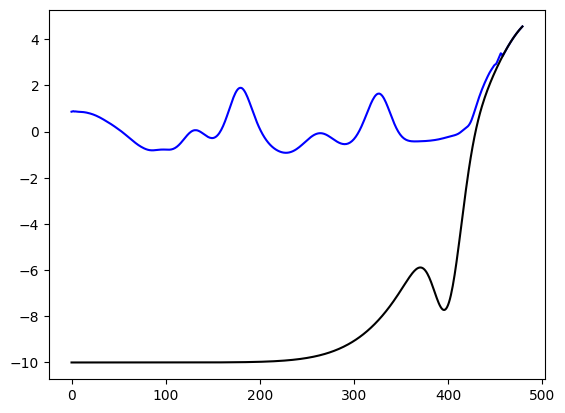

In [20]:
import matplotlib.pyplot as plt
# extract the coordinates
x_coord,zz =solver.domain.topofield()

#Send data to numpy
q = run.solver.State.to_numpy()
eta = q[:,0,0]
hu = q[:,0,1]
plt.plot(x_coord,eta,color='b')
plt.plot(x_coord,-zz,color='k')# make bathymetry negative